# 09 APIs para LLMs - API de gemini aplicada al Examen de Primer Bimestre 
## Sistema de Recuperación de Información

**Nombre:** Alexis Bautista  
**Fecha de entrega:** 30 de junio de 2026

### Carga de corpus

In [2]:
import pandas as pd

movies = pd.read_csv('corpus/rotten_tomatoes_movies.csv')
reviews = pd.read_csv('corpus/rotten_tomatoes_critic_reviews.csv')

# Agrupar las reseñas por película
#  une todas las reseñas de una misma película en un solo bloque de texto
reviews_grouped = reviews.groupby('rotten_tomatoes_link')['review_content'].apply(
    lambda x: ' '.join(x.dropna().astype(str))
).reset_index()

# Unir la información de las películas con sus reseñas agrupadas
df_corpus = pd.merge(movies, reviews_grouped, on='rotten_tomatoes_link', how='inner')

# Seleccionar los campos textuales relevantes y limpiar nulos
df_corpus = df_corpus.dropna(subset=['movie_title', 'movie_info', 'review_content']).reset_index(drop=True)

# Combinar el titulo, la sinopsis y las reseñas de los criticos
df_corpus['texto_completo'] = df_corpus['movie_title'] + ". " + df_corpus['movie_info'] + " " + df_corpus['review_content']

print ("El corpus se a cargado correctamente")

El corpus se a cargado correctamente


### 1. Preprocesamiento

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()


In [4]:
def preprocesar_texto(texto):
    
    # Conversión a minúsculas
    texto = texto.lower()
    
    # Eliminación de signos de puntuación
    texto = re.sub(r'[^\w\s]', ' ', texto)
    
    # tokenizacion
    tokens = texto.split()
    
    # Eliminación de stopwords
    tokens = [word for word in tokens if word not in stop_words]
    
    # Lematización
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    # Stemming    
    # tokens = [stemmer.stem(word) for word in tokens]
    
    # Unir tokens y eliminar de espacios redundantes
    texto = ' '.join(tokens)
    texto = re.sub(r'\s+', ' ', texto).strip()
    
    return texto

# preprocesamos
df_corpus['texto_limpio'] = df_corpus['texto_completo'].apply(preprocesar_texto)


print ("Se ha completado el preprocesado")
# df_corpus[['texto_completo', 'texto_limpio']].head(3)

Se ha completado el preprocesado


### 2. Generación de embeddings

In [6]:
from sentence_transformers import SentenceTransformer

# Cargar el modelo de embeddings
modelo = SentenceTransformer('all-MiniLM-L6-v2')

# Generar las representaciones vectoriales (embeddings)
print("Generando embeddings... Esto puede tomar un momento.")
embeddings_corpus = modelo.encode(df_corpus['texto_limpio'].tolist(), show_progress_bar=True)

# Verificacion 
print(f"Dimensiones de la matriz de embeddings: {embeddings_corpus.shape}")

c:\Users\Asus\Documents\Universidad\SEPTIMO SEMESTRE\RECUPERACION DE INFORMACION\RecuperacionInformacionEjercicios\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4573.31it/s]


Generando embeddings... Esto puede tomar un momento.


Batches: 100%|██████████| 544/544 [06:16<00:00,  1.44it/s]


Dimensiones de la matriz de embeddings: (17386, 384)


### 3. Procesamiento de consultas

In [7]:
from sklearn.metrics.pairwise import cosine_similarity

def procesar_consulta(query, modelo, corpus_embeddings):
    """
    Recibe una consulta textual, genera su embedding y la compara con el corpus.
    """
    # Recibir y preprocesar la consulta textual
    query_procesada = preprocesar_texto(query)
    
    # Generar su embedding
    query_embedding = modelo.encode([query_procesada])
    
    # Compararla con todos los documentos del corpus
    similitudes = cosine_similarity(query_embedding, corpus_embeddings)[0] # 0 para extraer la unidimensionalidad
    
    return similitudes

# verificacion
query = "science fiction movie with advanced technology"
similitudes_prueba = procesar_consulta(query, modelo, embeddings_corpus)

print(f"Consulta de prueba: '{query}'")
print(f"Total de documentos comparados: {similitudes_prueba.shape[0]}")
print(f"Ejemplo de puntajes de similitud coseno: {similitudes_prueba[:5]}")

Consulta de prueba: 'science fiction movie with advanced technology'
Total de documentos comparados: 17386
Ejemplo de puntajes de similitud coseno: [0.05333434 0.1296082  0.18917835 0.11299441 0.18714793]


### 4. Recuperación

In [8]:
def recuperar_top_k(similitudes, df, top_k=5):
    """
    Ordena los puntajes de similitud de mayor a menor y extrae los top_k documentos
    con los atributos requeridos por la evaluación.
    """
    # Obtener los índices de los 'top_k' documentos más similares
    # argsort() ordena los índices de menor a mayor score. 
    # Tomamos los últimos 'top_k' elementos y los invertimos con [::-1] para tener el orden descendente.
    indices_top = similitudes.argsort()[-top_k:][::-1]
    
    resultados = []
    
    # Construir la lista
    for ranking, idx in enumerate(indices_top, start=1):
        resultados.append({
            'Ranking': ranking,
            'ID documento': df['rotten_tomatoes_link'].iloc[idx],
            'Título película': df['movie_title'].iloc[idx],
            'Fragmento de texto': df['movie_info'].iloc[idx][:150] + "...", # Muestra representativa
            'Similitud': round(float(similitudes[idx]), 4) # Redondeo a 4 decimales para claridad técnica
        })
        
    return pd.DataFrame(resultados)

# Verificación del componente con la consulta de prueba del paso anterior
df_top_k_ejemplo = recuperar_top_k(similitudes_prueba, df_corpus, top_k=5)
df_top_k_ejemplo

,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,m/crack_in_the_world,Crack in the World,A dying scientist (Dana Andrews) and his team ...,0.4948
1,2,m/1013238-manhattan_project,The Manhattan Project,Ingenious adolescent Paul Stephens (Christophe...,0.4917
2,3,m/creator,Creator,With the help of student assistant Boris (Vinc...,0.4851
3,4,m/xchange,Xchange,Thriller set in a future in which people can t...,0.4819
4,5,m/philadelphia_experiment,The Philadelphia Experiment,"In 1943, a top-secret experiment aboard a Navy...",0.4761


### 5. Benchmark de consultas

In [9]:
consultas_benchmark = {
    "Q1": "science fiction movie with advanced technology",
    "Q2": "romantic story with emotional relationships",
    "Q3": "action movie with intense fight scenes",
    "Q4": "horror film that creates fear and suspense",
    "Q5": "visually impressive movie with weak storyline",
    "Q6": "emotionally moving performance by the lead actor",
    "Q7": "predictable plot but entertaining experience",
    "Q8": "movie praised by critics but unpopular with audiences"
}

resultados_completos = {}
datos_resumen_general = []

print("Iniciando Benchmark de Consultas...\n")

# Iterar sobre cada consulta
for id_q, texto_q in consultas_benchmark.items():
    print(f"Procesando {id_q}: '{texto_q}'")
    
    # A. Generar similitudes
    similitudes_q = procesar_consulta(texto_q, modelo, embeddings_corpus)
    
    # B. Recuperar el Top-5
    df_top_k = recuperar_top_k(similitudes_q, df_corpus, top_k=5)
    
    # C. Guardar el dataframe completo para mostrarlo luego
    resultados_completos[id_q] = df_top_k
    
    # D. Extraer el Top-1 para la tabla resumen
    # iloc[0] toma la primera fila (la de mayor similitud)
    top_1 = df_top_k.iloc[0]
    datos_resumen_general.append({
        'Consulta': f"{id_q}: {texto_q}",
        'Documento Top-1': top_1['ID documento'],
        'Título película': top_1['Título película'],
        'Similitud': top_1['Similitud']
    })

print("\n¡Benchmark completado con éxito!")

Iniciando Benchmark de Consultas...

Procesando Q1: 'science fiction movie with advanced technology'
Procesando Q2: 'romantic story with emotional relationships'
Procesando Q3: 'action movie with intense fight scenes'
Procesando Q4: 'horror film that creates fear and suspense'
Procesando Q5: 'visually impressive movie with weak storyline'
Procesando Q6: 'emotionally moving performance by the lead actor'
Procesando Q7: 'predictable plot but entertaining experience'
Procesando Q8: 'movie praised by critics but unpopular with audiences'

¡Benchmark completado con éxito!


### Tablas de resultados

In [10]:
from IPython.display import display, HTML

print(" TABLAS DE RESULTADOS POR CONSULTA (TOP-5)")

for id_q, df_resultados in resultados_completos.items():
    print(f"\nResultados para la consulta {id_q}:")
    display(df_resultados)

print("\n")
print(" TABLA RESUMEN GENERAL (MEJOR RESULTADO)")

# visualizacion como tabla
df_resumen_general = pd.DataFrame(datos_resumen_general)
display(df_resumen_general)

 TABLAS DE RESULTADOS POR CONSULTA (TOP-5)

Resultados para la consulta Q1:


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,m/crack_in_the_world,Crack in the World,A dying scientist (Dana Andrews) and his team ...,0.4948
1,2,m/1013238-manhattan_project,The Manhattan Project,Ingenious adolescent Paul Stephens (Christophe...,0.4917
2,3,m/creator,Creator,With the help of student assistant Boris (Vinc...,0.4851
3,4,m/xchange,Xchange,Thriller set in a future in which people can t...,0.4819
4,5,m/philadelphia_experiment,The Philadelphia Experiment,"In 1943, a top-secret experiment aboard a Navy...",0.4761



Resultados para la consulta Q2:


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,m/2_in_the_bush_a_love_story_2019,2 in the Bush: A Love Story,"After her relationship ends badly, a woman get...",0.5214
1,2,m/falling_in_love,Falling in Love,"Commuting to Manhattan on the same train, two ...",0.5192
2,3,m/1_night,1 Night (One Night),Past and present collide as two couples explor...,0.5087
3,4,m/three_times,Three Times (Zui hao de shi guang),Three romantic tales take place in different e...,0.4831
4,5,m/sweet_hearts_dance,Sweet Hearts Dance,Sandra (Susan Sarandon) and Wiley (Don Johnson...,0.4670



Resultados para la consulta Q3:


...

,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,m/house_in_the_alley,House In The Alley,Thao and Thanh experience strange phenomena an...,0.5187
1,2,m/flickering_lights,Flickering Lights,Four gangsters steal a fortune from their boss...,0.5074
2,3,m/i_inside,The I Inside,"After a near-death experience, a man (Ryan Phi...",0.4983
3,4,m/tales_from_the_hood_2,Tales from the Hood 2,"A series of bloodcurdling tales about lust, gr...",0.4906
4,5,m/1037177-deceived,Deceived,The murder of a museum curator places art deal...,0.4862



Resultados para la consulta Q8:


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,m/10010957-polanski_unauthorized,Polanski (Polanski Unauthorized),Filmmaker Roman Polanski (Damian Chapa) courts...,0.4199
1,2,m/network,Network,"In this lauded satire, veteran news anchorman ...",0.4172
2,3,m/the_starving_games,The Starving Games,"Spoofs ""The Hunger Games,"" ""Avengers"" and Harr...",0.4125
3,4,m/bad_taste,Bad Taste,Gun-toting assassins try to wipe out a group o...,0.4108
4,5,m/meeting_evil_2012,Meeting Evil,An unwitting family man (Luke Wilson) takes a ...,0.4030




 TABLA RESUMEN GENERAL (MEJOR RESULTADO)


,Consulta,Documento Top-1,Título película,Similitud
0,Q1: science fiction movie with advanced techno...,m/crack_in_the_world,Crack in the World,0.4948
1,Q2: romantic story with emotional relationships,m/2_in_the_bush_a_love_story_2019,2 in the Bush: A Love Story,0.5214
2,Q3: action movie with intense fight scenes,m/the_challenge_1982,The Challenge,0.5515
3,Q4: horror film that creates fear and suspense,m/the_church,The Church (La Chiesa),0.6083
4,Q5: visually impressive movie with weak storyline,m/impossible_monsters,Impossible Monsters,0.5457
5,Q6: emotionally moving performance by the lead...,m/i_am_jonas,I Am Jonas (Jonas),0.4696
6,Q7: predictable plot but entertaining experience,m/house_in_the_alley,House In The Alley,0.5187
7,Q8: movie praised by critics but unpopular wit...,m/10010957-polanski_unauthorized,Polanski (Polanski Unauthorized),0.4199


### 6. Desafío de excelencia

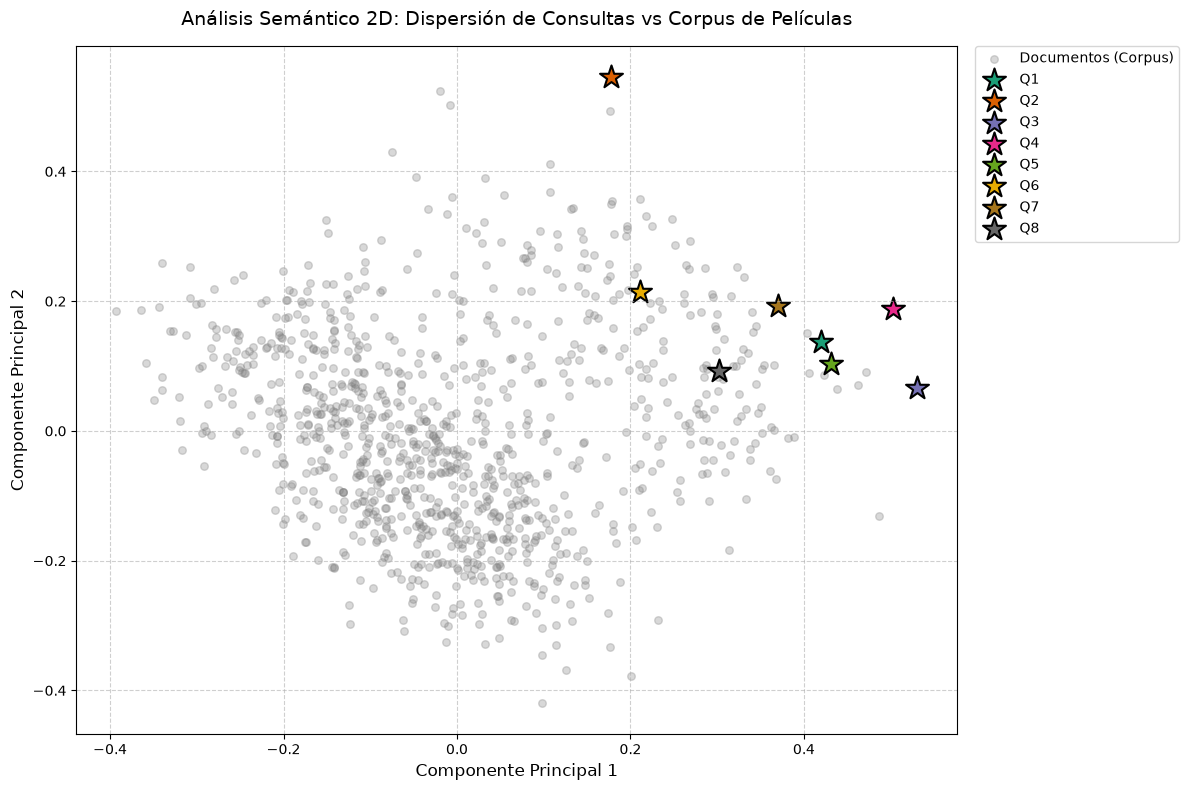

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Visualización PCA

# Muestreo del corpus (1000 documentos) 
np.random.seed(42)
indices_muestra = np.random.choice(embeddings_corpus.shape[0], size=1000, replace=False)
corpus_muestra = embeddings_corpus[indices_muestra]

# Procesar y vectorizar las 8 consultas
nombres_consultas = list(consultas_benchmark.keys())
textos_consultas = [preprocesar_texto(q) for q in consultas_benchmark.values()]
embeddings_consultas = modelo.encode(textos_consultas)

# Concatenar matrices y aplicar PCA para reducir de 384 a 2 dimensiones
matriz_combinada = np.vstack((corpus_muestra, embeddings_consultas))
pca = PCA(n_components=2)
coordenadas_2d = pca.fit_transform(matriz_combinada)

# Separar las coordenadas proyectadas
coords_corpus = coordenadas_2d[:1000]
coords_consultas = coordenadas_2d[1000:]

plt.figure(figsize=(12, 8))
plt.style.use('default')

# Graficar puntos del corpus
plt.scatter(coords_corpus[:, 0], coords_corpus[:, 1], 
            alpha=0.3, c='gray', s=30, label='Documentos (Corpus)')

# Graficar las posiciones de las consultas
colores = plt.cm.Dark2(np.linspace(0, 1, len(nombres_consultas)))
for i, (nombre, color) in enumerate(zip(nombres_consultas, colores)):
    plt.scatter(coords_consultas[i, 0], coords_consultas[i, 1], 
                c=[color], s=300, marker='*', edgecolors='black', 
                linewidth=1.5, label=f'{nombre}')

plt.title('Análisis Semántico 2D: Dispersión de Consultas vs Corpus de Películas', fontsize=14, pad=15)
plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Renderizado final
plt.show()

# 09 APIs para LLMs

#### Configuración y Función del Chatbot

Esta función tomará la consulta original, los resultados que arrojó la función recuperar_top_k y tu API Key, y construirá el prompt

In [18]:
import google.generativeai as genai
from IPython.display import display, Markdown

def generar_respuesta_chatbot(query, df_resultados, api_key):
    """
    Toma los resultados del SRI y genera una respuesta en lenguaje natural usando Gemini.
    """
    # 1. Configurar la API Key
    genai.configure(api_key=api_key)
    
    # Usamos el modelo flash porque es rápido y excelente para tareas de lectura de contexto
    modelo_llm = genai.GenerativeModel('gemini-2.5-flash')
    
    # 2. Formatear los resultados del SRI para que Gemini los entienda
    contexto_sri = ""
    for index, row in df_resultados.iterrows():
        contexto_sri += f"- **Película:** {row['Título película']}\n"
        contexto_sri += f"  **Sinopsis/Review:** {row['Fragmento de texto']}\n\n"
        
    # 3. Construir el prompt en formato Markdown
    prompt = f"""Mi usuario quiere saber: **{query}** Y mi SRI encontro los siguientes resultados:

{contexto_sri}

Dame la respuesta en base al contexto dado por el SRI.
"""
    
    # 4. Generar la respuesta con Gemini
    try:
        respuesta = modelo_llm.generate_content(prompt)
        # Mostrar el prompt utilizado 
        print("--- PROMPT ENVIADO A GEMINI ---")
        print(prompt)
        print("-------------------------------\n")
        
        return respuesta.text
    except Exception as e:
        return f"Error al conectar con Gemini: {e}"

#### Ejecución de prueba

In [ ]:
API_KEY = "API_KEY" 

# Tomamos una consulta de prueba
query_chatbot = "science fiction movie with advanced technology"

# 1. Buscamos en el SRI 
similitudes = procesar_consulta(query_chatbot, modelo, embeddings_corpus)
df_top5 = recuperar_top_k(similitudes, df_corpus, top_k=5)

# 2. Pasamos el contexto al Chatbot
respuesta_final = generar_respuesta_chatbot(query_chatbot, df_top5,API_KEY)

print("RESPUESTA DEL CHATBOT:")
display(Markdown(respuesta_final))

--- PROMPT ENVIADO A GEMINI ---
Mi usuario quiere saber: **science fiction movie with advanced technology** Y mi SRI encontro los siguientes resultados:

- **Película:** Crack in the World
  **Sinopsis/Review:** A dying scientist (Dana Andrews) and his team drill for magma, crack the globe and try to fix it with a nuclear bomb....

- **Película:** The Manhattan Project
  **Sinopsis/Review:** Ingenious adolescent Paul Stephens (Christopher Collet) learns about the grim prospects of nuclear aftermath when his mom becomes romantically involve...

- **Película:** Creator
  **Sinopsis/Review:** With the help of student assistant Boris (Vincent Spano) and stolen university equipment, Dr. Harry Wolper (Peter O'Toole) plans to clone his dead wif...

- **Película:** Xchange
  **Sinopsis/Review:** Thriller set in a future in which people can travel across the globe by swapping bodies with someone at their destination. A businessman discovers tha...

- **Película:** The Philadelphia Experiment
  

Basado en el contexto proporcionado por el SRI, las películas que presentan tecnología avanzada son:

*   **Creator:** En esta película, el Dr. Harry Wolper (Peter O'Toole) planea **clonar a su difunta esposa**, lo que implica el uso de tecnología avanzada de clonación.
*   **Xchange:** Ambientada en un futuro, esta película describe un sistema donde las personas pueden viajar por el mundo **intercambiando cuerpos** con alguien en su destino, lo que representa una tecnología muy avanzada para el transporte y la conciencia.
*   **The Philadelphia Experiment:** Aquí, un experimento secreto a bordo de un destructor de la Marina en 1943 provoca que dos marineros sean **propulsados a 1984**, lo que sugiere una tecnología avanzada relacionada con viajes en el tiempo o la manipulación del espacio-tiempo.